In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from xgboost import XGBClassifier

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 50000

modules = [
    "ALU",
    "Instruction_Decoder",
    "Memory_Controller",
    "Cache_Controller",
    "Bus_Interface",
    "DMA_Engine",
    "Interrupt_Controller"
]

tests = [
    "memory_stress_test",
    "cache_eviction_test",
    "interrupt_test",
    "dma_transfer_test",
    "alu_overflow_test",
    "pipeline_test",
    "bus_protocol_test"
]

errors = [
    "None",
    "Assertion Failure",
    "Timing Violation",
    "Protocol Error",
    "Overflow",
    "Deadlock"
]

data = {
    "regression_id": np.random.randint(1000, 2000, n),
    "test_name": np.random.choice(tests, n),
    "module": np.random.choice(modules, n),
    "seed": np.random.randint(1, 100000, n),
    "code_coverage": np.random.uniform(50, 100, n),
    "functional_coverage": np.random.uniform(40, 100, n),
    "assertions_failed": np.random.randint(0, 5, n),
    "simulation_time": np.random.uniform(20, 500, n),
    "lines_modified": np.random.randint(0, 200, n),
    "prior_failures": np.random.randint(0, 10, n),
    "engineer_experience": np.random.randint(1, 10, n),
    "error_type": np.random.choice(errors, n)
}

df = pd.DataFrame(data)

# realistic failure probability
failure_score = (
    (100 - df["code_coverage"]) * 0.03
    + (100 - df["functional_coverage"]) * 0.02
    + df["lines_modified"] * 0.01
    + df["prior_failures"] * 0.3
    + df["assertions_failed"] * 0.4
)

df["result"] = (failure_score > 4).astype(int)

df.to_csv("rtl_verification_dataset.csv", index=False)

print("Dataset generated:", df.shape)

Dataset generated: (50000, 13)


In [ ]:
df = pd.read_csv("rtl_verification_dataset.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (50000, 13)


,regression_id,test_name,module,seed,code_coverage,functional_coverage,assertions_failed,simulation_time,lines_modified,prior_failures,engineer_experience,error_type,result
0,1102,memory_stress_test,Interrupt_Controller,72109,89.382281,51.382241,2,33.770444,199,0,8,Deadlock,1
1,1435,bus_protocol_test,DMA_Engine,80300,92.480891,67.884499,2,422.344208,186,2,4,Assertion Failure,1
2,1860,interrupt_test,Instruction_Decoder,74181,83.331917,94.724591,2,150.150807,13,1,1,Assertion Failure,0
3,1270,dma_transfer_test,Instruction_Decoder,87168,51.866267,80.623254,1,167.879798,140,8,4,NaN,1
4,1106,dma_transfer_test,DMA_Engine,57053,67.623889,46.197379,1,229.378158,1,9,1,Protocol Error,1


In [ ]:
df = df.drop(
    columns=[
        "regression_id",
        "seed",
        "error_type"
    ],
    errors="ignore"
)

df.head()

,test_name,module,code_coverage,functional_coverage,assertions_failed,simulation_time,lines_modified,prior_failures,engineer_experience,result
0,memory_stress_test,Interrupt_Controller,89.382281,51.382241,2,33.770444,199,0,8,1
1,bus_protocol_test,DMA_Engine,92.480891,67.884499,2,422.344208,186,2,4,1
2,interrupt_test,Instruction_Decoder,83.331917,94.724591,2,150.150807,13,1,1,0
3,dma_transfer_test,Instruction_Decoder,51.866267,80.623254,1,167.879798,140,8,4,1
4,dma_transfer_test,DMA_Engine,67.623889,46.197379,1,229.378158,1,9,1,1


In [ ]:
# Feature Engineering

if "lines_changed" in df.columns and "previous_failures" in df.columns:
    df["change_risk"] = df["lines_changed"] * df["previous_failures"]

if "previous_failures" in df.columns and "days_since_last_change" in df.columns:
    df["failure_density"] = df["previous_failures"] / (df["days_since_last_change"] + 1)

if "lines_changed" in df.columns and "coverage_gain" in df.columns:
    df["change_intensity"] = df["lines_changed"] / (df["coverage_gain"] + 0.1)

if "lines_changed" in df.columns and "previous_failures" in df.columns and "coverage_gain" in df.columns:
    df["risk_score"] = (
        df["lines_changed"] * 0.4 +
        df["previous_failures"] * 0.4 +
        df["coverage_gain"] * 0.2
    )

df.head()

,test_name,module,code_coverage,functional_coverage,assertions_failed,simulation_time,lines_modified,prior_failures,engineer_experience,result
0,memory_stress_test,Interrupt_Controller,89.382281,51.382241,2,33.770444,199,0,8,1
1,bus_protocol_test,DMA_Engine,92.480891,67.884499,2,422.344208,186,2,4,1
2,interrupt_test,Instruction_Decoder,83.331917,94.724591,2,150.150807,13,1,1,0
3,dma_transfer_test,Instruction_Decoder,51.866267,80.623254,1,167.879798,140,8,4,1
4,dma_transfer_test,DMA_Engine,67.623889,46.197379,1,229.378158,1,9,1,1


In [ ]:
categorical_cols = df.select_dtypes(include="object").columns

print("Encoding columns:", categorical_cols)

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

df.head()

Encoding columns: Index(['test_name', 'module'], dtype='object')


,code_coverage,functional_coverage,assertions_failed,simulation_time,lines_modified,prior_failures,engineer_experience,result,test_name_bus_protocol_test,test_name_cache_eviction_test,test_name_dma_transfer_test,test_name_interrupt_test,test_name_memory_stress_test,test_name_pipeline_test,module_Bus_Interface,module_Cache_Controller,module_DMA_Engine,module_Instruction_Decoder,module_Interrupt_Controller,module_Memory_Controller
0,89.382281,51.382241,2,33.770444,199,0,8,1,False,False,False,False,True,False,False,False,False,False,True,False
1,92.480891,67.884499,2,422.344208,186,2,4,1,True,False,False,False,False,False,False,False,True,False,False,False
2,83.331917,94.724591,2,150.150807,13,1,1,0,False,False,False,True,False,False,False,False,False,True,False,False
3,51.866267,80.623254,1,167.879798,140,8,4,1,False,False,True,False,False,False,False,False,False,True,False,False
4,67.623889,46.197379,1,229.378158,1,9,1,1,False,False,True,False,False,False,False,False,True,False,False,False


In [ ]:
X = df.drop("result", axis=1)

y = df["result"]

print("Features:", len(X.columns))

Features: 19


In [ ]:
df = df.rename(columns={
    "lines_modified": "lines_changed",
    "prior_failures": "previous_failures",
    "result": "pass_fail"
})

In [ ]:
df["change_risk"] = df["lines_changed"] * df["previous_failures"]

In [ ]:
df.to_csv("rtl_verification_dataset_clean.csv", index=False)

In [ ]:
import pandas as pd

df = pd.read_csv("rtl_verification_dataset_clean.csv")

print(df.head())
print(df.info())
print(df.describe())

   code_coverage  functional_coverage  assertions_failed  simulation_time  \
0      89.382281            51.382241                  2        33.770444   
1      92.480891            67.884499                  2       422.344208   
2      83.331917            94.724591                  2       150.150807   
3      51.866267            80.623254                  1       167.879798   
4      67.623889            46.197379                  1       229.378158   

   lines_changed  previous_failures  engineer_experience  pass_fail  \
0            199                  0                    8          1   
1            186                  2                    4          1   
2             13                  1                    1          0   
3            140                  8                    4          1   
4              1                  9                    1          1   

   test_name_bus_protocol_test  test_name_cache_eviction_test  ...  \
0                        False          

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.9837
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      3487
           1       0.99      0.99      0.99      6513

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
from sklearn.metrics import roc_auc_score

probs = model.predict_proba(X_test)[:,1]

print("ROC AUC:", roc_auc_score(y_test, probs))

ROC AUC: 0.9991855427923356


In [ ]:
# Example new verification run

sample = pd.DataFrame({
    "code_coverage": [70],
    "functional_coverage": [65],
    "assertions_failed": [2],
    "simulation_time": [200],
    "lines_modified": [120],
    "prior_failures": [5],
    "engineer_experience": [3],
    "risk_score": [120*0.3 + 5*2 + 2*3]
})

# Add missing encoded columns
sample = sample.reindex(columns=X.columns, fill_value=0)

# Predict result
prediction = model.predict(sample)

# Predict probability
prob = model.predict_proba(sample)

print("Prediction (0 = Pass, 1 = Fail):", prediction[0])
print("Failure Probability:", prob[0][1])

Prediction (0 = Pass, 1 = Fail): 1
Failure Probability: 0.99992156


In [ ]:
examples = pd.DataFrame({

    "code_coverage":[95, 75, 60],
    "functional_coverage":[90, 70, 55],
    "assertions_failed":[0, 2, 4],
    "simulation_time":[150, 220, 300],
    "lines_modified":[20, 90, 160],
    "prior_failures":[1, 4, 8],
    "engineer_experience":[8, 5, 2]

})

# create risk score
examples["risk_score"] = (
    examples["lines_modified"]*0.3 +
    examples["prior_failures"]*2 +
    examples["assertions_failed"]*3
)

# match training columns
examples = examples.reindex(columns=X.columns, fill_value=0)

# predictions
predictions = model.predict(examples)
probabilities = model.predict_proba(examples)[:,1]

results = pd.DataFrame({
    "Prediction (0=Pass,1=Fail)": predictions,
    "Failure Probability": probabilities
})

print(results)

   Prediction (0=Pass,1=Fail)  Failure Probability
0                           0         1.143271e-07
1                           1         9.377670e-01
2                           1         1.000000e+00


In [ ]:
# Predict failure probability for entire dataset

df["failure_probability"] = model.predict_proba(X)[:,1]

# sort by risk
risk_ranking = df.sort_values(by="failure_probability", ascending=False)

risk_ranking.head(10)

,code_coverage,functional_coverage,assertions_failed,simulation_time,lines_changed,previous_failures,engineer_experience,pass_fail,test_name_bus_protocol_test,test_name_cache_eviction_test,...,test_name_memory_stress_test,test_name_pipeline_test,module_Bus_Interface,module_Cache_Controller,module_DMA_Engine,module_Instruction_Decoder,module_Interrupt_Controller,module_Memory_Controller,change_risk,failure_probability
37492,51.584106,47.570965,4,226.380548,171,7,7,1,False,False,...,True,False,False,False,False,True,False,False,1197,1.0
2539,50.928260,44.617339,4,302.347479,194,6,1,1,False,False,...,True,False,False,False,True,False,False,False,1164,1.0
49900,52.236183,42.462458,3,137.205341,117,9,7,1,False,False,...,False,False,False,False,False,False,False,True,1053,1.0
43312,54.835474,50.737517,3,393.909582,151,8,5,1,False,False,...,False,False,False,False,False,False,False,True,1208,1.0
43289,54.034666,48.955334,3,133.257676,156,9,4,1,False,False,...,False,True,False,True,False,False,False,False,1404,1.0
24203,54.635023,64.832343,4,220.441105,146,9,2,1,False,True,...,False,False,False,False,False,True,False,False,1314,1.0
39838,54.436298,44.433071,4,316.607896,155,5,7,1,False,True,...,False,False,False,False,False,False,False,True,775,1.0
43378,52.842601,49.706500,4,355.598222,107,9,2,1,False,False,...,False,False,False,False,False,False,False,False,963,1.0
33437,65.220551,51.060284,4,105.891888,179,7,6,1,False,False,...,True,False,False,False,False,False,True,False,1253,1.0
33306,51.272528,42.529736,4,190.915594,95,9,2,1,False,True,...,False,False,False,True,False,False,False,False,855,1.0


In [ ]:
#similarity
from sklearn.neighbors import NearestNeighbors

# automatically select numeric columns
features = df.select_dtypes(include=["int64", "float64"])

print("Using features:", features.columns)

# build nearest neighbor model
nn = NearestNeighbors(n_neighbors=5)

nn.fit(features)

Using features: Index(['code_coverage', 'functional_coverage', 'assertions_failed',
       'simulation_time', 'lines_changed', 'previous_failures',
       'engineer_experience', 'pass_fail', 'change_risk'],
      dtype='object')


NearestNeighbors()

In [ ]:
def find_similar_runs(index):

    query = features.iloc[[index]]

    distances, indices = nn.kneighbors(query)

    return df.iloc[indices[0]]

In [ ]:
find_similar_runs(0)

,code_coverage,functional_coverage,assertions_failed,simulation_time,lines_changed,previous_failures,engineer_experience,pass_fail,test_name_bus_protocol_test,test_name_cache_eviction_test,...,test_name_memory_stress_test,test_name_pipeline_test,module_Bus_Interface,module_Cache_Controller,module_DMA_Engine,module_Instruction_Decoder,module_Interrupt_Controller,module_Memory_Controller,change_risk,failure_probability
0,89.382281,51.382241,2,33.770444,199,0,8,1,False,False,...,True,False,False,False,False,False,True,False,0,0.847445
39197,97.354222,47.038527,3,42.600264,190,0,8,1,False,True,...,False,False,False,False,False,False,False,True,0,0.914428
29595,81.750440,62.113360,3,37.408282,192,0,1,1,False,True,...,False,False,False,False,False,True,False,False,0,0.977470
31778,95.192591,63.994998,3,31.330447,188,0,4,0,False,False,...,False,False,False,False,False,True,False,False,0,0.244378
28283,96.533034,62.834513,4,44.864339,190,0,5,1,False,False,...,False,False,False,False,True,False,False,False,0,0.884884


In [ ]:
# regression plan
def smart_regression_plan(df, time_budget):

    sorted_df = df.sort_values(
        by="failure_probability",
        ascending=False
    )

    selected = []
    runtime = 0

    for i, row in sorted_df.iterrows():

        test_time = np.random.randint(20,120)

        if runtime + test_time <= time_budget:

            selected.append(i)   # use index instead of test_name
            runtime += test_time

    return selected, runtime


tests, runtime = smart_regression_plan(risk_ranking, 500)

print("Selected Test Indices:", tests)
print("Total Runtime:", runtime)

Selected Test Indices: [32291, 47356, 14845, 28631, 41225, 41251]
Total Runtime: 492


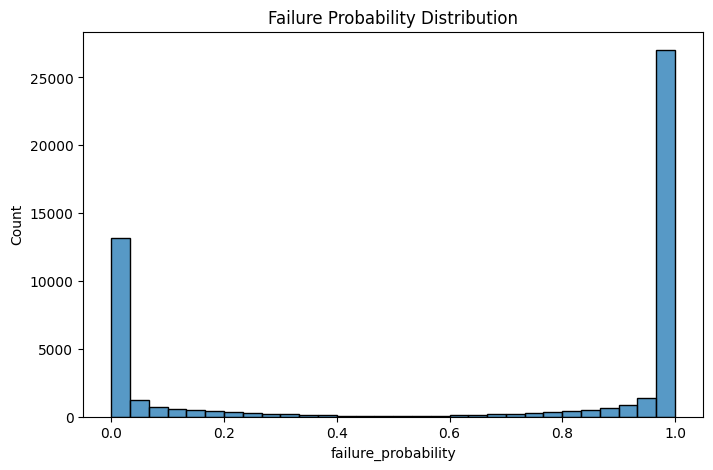

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["failure_probability"], bins=30)

plt.title("Failure Probability Distribution")

plt.show()

In [ ]:
def show_error_details(index):

    row = df.iloc[index]

    print("------ Verification Run Details ------")

    print("Module:", row.get("module", "N/A"))
    print("Test Name:", row.get("test_name", "N/A"))

    print("\nCoverage Information")
    print("Code Coverage:", row.get("code_coverage", "N/A"))
    print("Functional Coverage:", row.get("functional_coverage", "N/A"))

    print("\nFailure Indicators")
    print("Assertions Failed:", row.get("assertions_failed", "N/A"))
    print("Lines Modified:", row.get("lines_modified", "N/A"))
    print("Prior Failures:", row.get("prior_failures", "N/A"))

    print("\nEngineer Info")
    print("Engineer Experience:", row.get("engineer_experience", "N/A"))

    if "failure_probability" in df.columns:
        print("\nAI Prediction")
        print("Failure Probability:", round(row["failure_probability"],3))

    if "result" in df.columns:
        status = "FAIL" if row["result"] == 1 else "PASS"
        print("Actual Result:", status)

In [ ]:
show_error_details(0)

------ Verification Run Details ------
Module: N/A
Test Name: N/A

Coverage Information
Code Coverage: 89.38228110340587
Functional Coverage: 51.382241469281

Failure Indicators
Assertions Failed: 2
Lines Modified: N/A
Prior Failures: N/A

Engineer Info
Engineer Experience: 8

AI Prediction
Failure Probability: 0.847


In [ ]:
import json
from datetime import datetime

def generate_failure_log(index):

    row = df.iloc[index]

    # determine status safely
    if "result" in df.columns:
        status = "FAIL" if row["result"] == 1 else "PASS"
    else:
        status = "UNKNOWN"

    log = {
        "run_id": f"HIST-{1000+index}",
        "timestamp": datetime.now().isoformat(),

        "test_name": row.get("test_name", "unknown"),
        "status": status,

        "hardware_context": {
            "module_path": row.get("module", "unknown"),
            "assertion_name": f"assert_{row.get('module','module').lower()}_check"
        },

        "error_details": {
            "error_signature": "ASSERTION_FAILURE" if row.get("assertions_failed",0) > 0 else "TIMEOUT",
            "error_text": f"{row.get('assertions_failed',0)} assertions failed during simulation",
            "bug_type": "Protocol_Violation" if row.get("assertions_failed",0) > 2 else "Logic_Error"
        },

        "ml_features": {
            "risk_score_at_time": float(row.get("risk_score",0)),
            "failure_probability": float(row.get("failure_probability",0))
        }
    }

    print(json.dumps(log, indent=2))


generate_failure_log(5)

{
  "run_id": "HIST-1005",
  "timestamp": "2026-03-06T06:36:22.022414",
  "test_name": "unknown",
  "status": "UNKNOWN",
  "hardware_context": {
    "module_path": "unknown",
    "assertion_name": "assert_module_check"
  },
  "error_details": {
    "error_signature": "ASSERTION_FAILURE",
    "error_text": "2 assertions failed during simulation",
    "bug_type": "Logic_Error"
  },
  "ml_features": {
    "risk_score_at_time": 0.0,
    "failure_probability": 0.0006660395883955061
  }
}
